In [1]:
# =====================================================
# PREDICTIVE MAINTENANCE OF INDUSTRIAL MACHINERY
# =====================================================

# -------------------------------
# IMPORT LIBRARIES
# -------------------------------

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

from sklearn.ensemble import RandomForestClassifier

from imblearn.over_sampling import SMOTE

import joblib

In [1]:

import os, types
import pandas as pd
from botocore.client import Config
import ibm_boto3

def __iter__(self): return 0

# @hidden_cell
# The following code accesses a file in your IBM Cloud Object Storage. It includes your credentials.
# You might want to remove those credentials before you share the notebook.

cos_client = ibm_boto3.client(service_name='s3',
    ibm_api_key_id='_6hDDmWN2xqqhNpEc-LTF5xJIzZzkQb2f0YYxIM2E0to',
    ibm_auth_endpoint="https://iam.cloud.ibm.com/identity/token",
    config=Config(signature_version='oauth'),
    endpoint_url='https://s3.direct.us-south.cloud-object-storage.appdomain.cloud')

bucket = 'adrishaicteinternshipproject-donotdelete-pr-vez93lhghbamb9'
object_key = 'predictive_maintenance.csv'

body = cos_client.get_object(Bucket=bucket,Key=object_key)['Body']
# add missing __iter__ method, so pandas accepts body as file-like object
if not hasattr(body, "__iter__"): body.__iter__ = types.MethodType( __iter__, body )

df_1 = pd.read_csv(body)
df_1.head(10)


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,No Failure
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,No Failure
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,No Failure
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,No Failure
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,No Failure
5,6,M14865,M,298.1,308.6,1425,41.9,11,0,No Failure
6,7,L47186,L,298.1,308.6,1558,42.4,14,0,No Failure
7,8,L47187,L,298.1,308.6,1527,40.2,16,0,No Failure
8,9,M14868,M,298.3,308.7,1667,28.6,18,0,No Failure
9,10,M14869,M,298.5,309.0,1741,28.0,21,0,No Failure


In [4]:
df = df_1.copy()

In [5]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicates:")
print(df.duplicated().sum())

print("\nFailure Type Distribution:")
print(df['Failure Type'].value_counts())

Shape: (10000, 10)

Columns:
Index(['UDI', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Target', 'Failure Type'],
      dtype='object')

Data Types:
UDI                          int64
Product ID                  object
Type                        object
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Target                       int64
Failure Type                object
dtype: object

Missing Values:
UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Target                     0
Failure Type               0
dtype: int64

Duplicates:
0

Failure Type Distribution:
Failure Type
No Failur

In [6]:
# Remove duplicate rows

df.drop_duplicates(inplace=True)

# Remove unnecessary columns

df.drop(['UDI','Product ID'], axis=1, inplace=True)

print(df.shape)

(10000, 8)


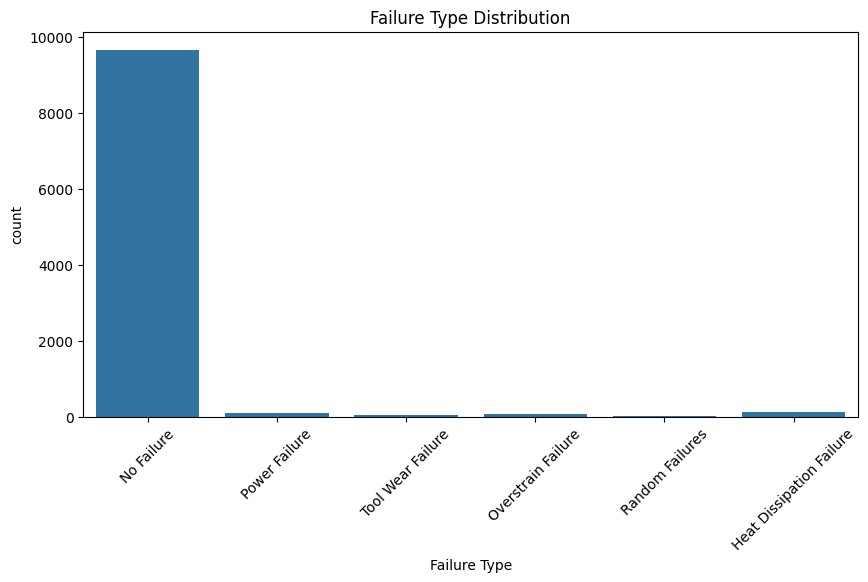

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x='Failure Type'
)

plt.xticks(rotation=45)
plt.title("Failure Type Distribution")

plt.show()

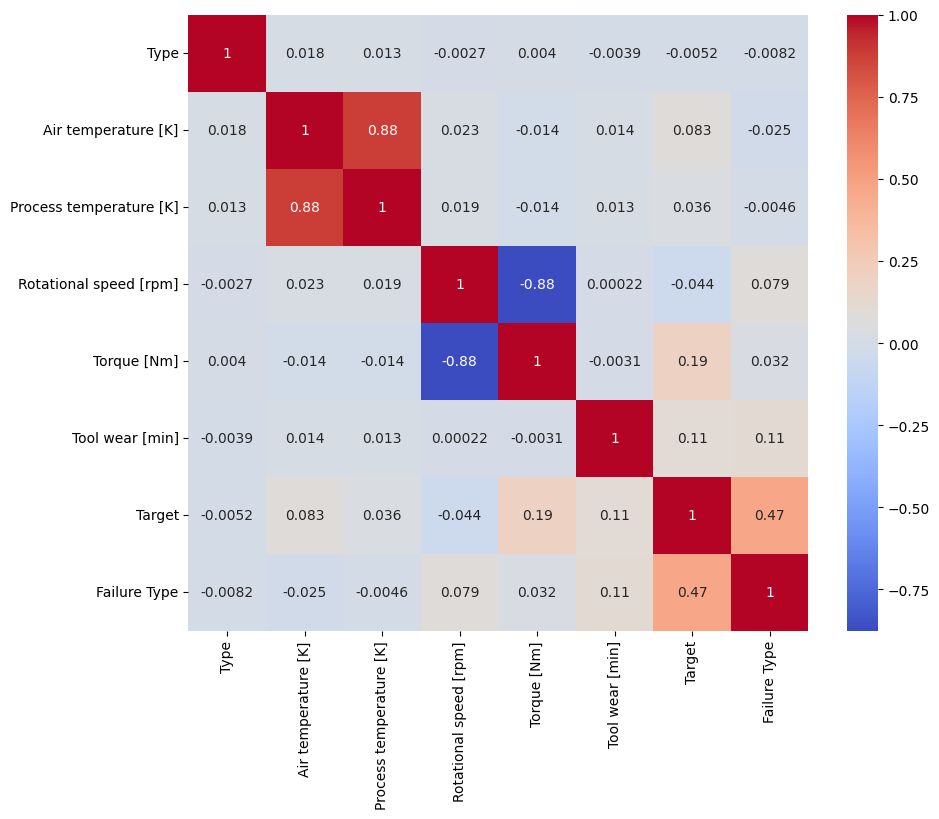

In [8]:
from sklearn.preprocessing import LabelEncoder

temp = df.copy()

le = LabelEncoder()

temp['Type'] = le.fit_transform(temp['Type'])
temp['Failure Type'] = le.fit_transform(temp['Failure Type'])

plt.figure(figsize=(10,8))

sns.heatmap(
    temp.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.show()

In [9]:
# Temperature Difference

df['Temperature_Difference'] = (
    df['Process temperature [K]']
    -
    df['Air temperature [K]']
)

# Estimated Power

df['Power'] = (
    df['Rotational speed [rpm]']
    *
    df['Torque [Nm]']
)

# Wear Rate

df['Wear_Rate'] = (
    df['Tool wear [min]']
    /
    (df['Rotational speed [rpm]'] + 1)
)

df.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type,Temperature_Difference,Power,Wear_Rate
0,M,298.1,308.6,1551,42.8,0,0,No Failure,10.5,66382.8,0.000000
1,L,298.2,308.7,1408,46.3,3,0,No Failure,10.5,65190.4,0.002129
2,L,298.1,308.5,1498,49.4,5,0,No Failure,10.4,74001.2,0.003336
3,L,298.2,308.6,1433,39.5,7,0,No Failure,10.4,56603.5,0.004881
4,L,298.2,308.7,1408,40.0,9,0,No Failure,10.5,56320.0,0.006388


In [11]:
from sklearn.preprocessing import LabelEncoder

type_encoder = LabelEncoder()

df['Type'] = type_encoder.fit_transform(
    df['Type']
)

target_encoder = LabelEncoder()

df['Failure Type'] = target_encoder.fit_transform(
    df['Failure Type']
)

In [12]:
X = df.drop(
    ['Failure Type','Target'],
    axis=1
)

y = df['Failure Type']

print(X.shape)
print(y.shape)

(10000, 9)
(10000,)


In [13]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(8000, 9)
(2000, 9)


In [14]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    random_state=42,
    class_weight='balanced'
)

rf.fit(
    X_train,
    y_train
)

RandomForestClassifier(class_weight='balanced', max_depth=15, n_estimators=300,
                       random_state=42)

In [17]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        22
           1       0.99      1.00      0.99      1930
           2       0.78      0.44      0.56        16
           3       1.00      1.00      1.00        19
           4       0.00      0.00      0.00         4
           5       0.00      0.00      0.00         9

    accuracy                           0.98      2000
   macro avg       0.63      0.57      0.59      2000
weighted avg       0.98      0.98      0.98      2000



In [18]:
y_pred = rf.predict(X_test)

In [20]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", round(accuracy*100,2), "%")

Model Accuracy: 98.5 %


In [21]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        22
           1       0.99      1.00      0.99      1930
           2       0.78      0.44      0.56        16
           3       1.00      1.00      1.00        19
           4       0.00      0.00      0.00         4
           5       0.00      0.00      0.00         9

    accuracy                           0.98      2000
   macro avg       0.63      0.57      0.59      2000
weighted avg       0.98      0.98      0.98      2000



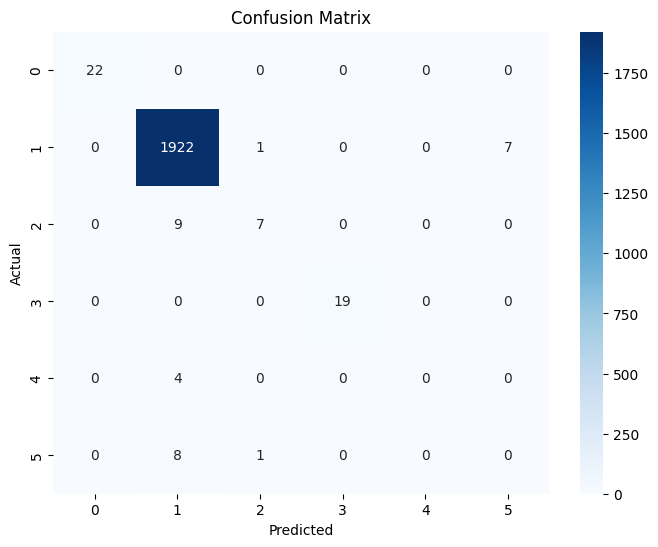

In [22]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [23]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

                   Feature  Importance
7                    Power    0.207062
5          Tool wear [min]    0.152180
6   Temperature_Difference    0.151620
4              Torque [Nm]    0.138426
8                Wear_Rate    0.134218
3   Rotational speed [rpm]    0.122908
1      Air temperature [K]    0.041221
2  Process temperature [K]    0.041113
0                     Type    0.011251


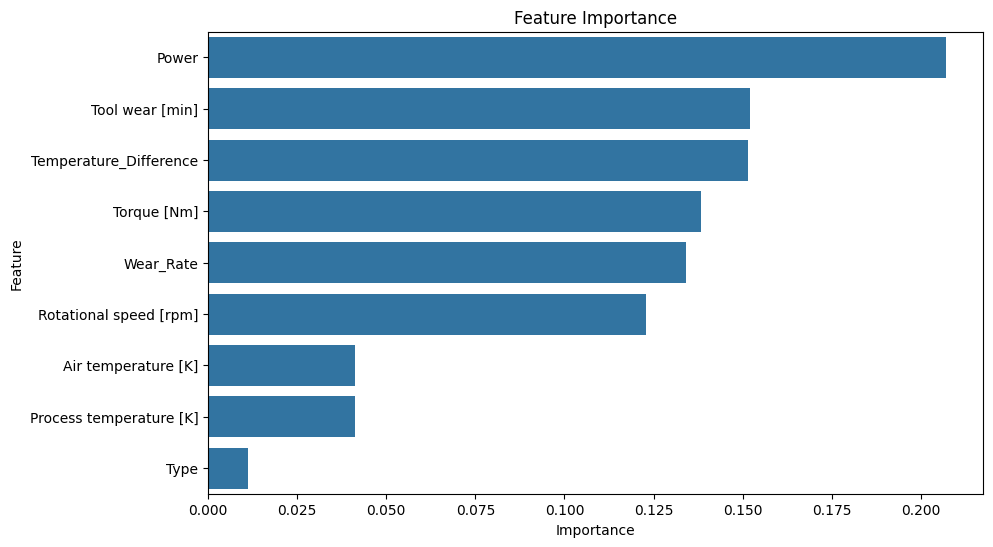

In [24]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance,
    x='Importance',
    y='Feature'
)

plt.title("Feature Importance")
plt.show()

In [25]:
import joblib

joblib.dump(
    rf,
    "predictive_maintenance_model.pkl"
)

print("Model saved successfully.")

Model saved successfully.


In [26]:
sample = pd.DataFrame({

    'Type':[1],

    'Air temperature [K]':[298.0],

    'Process temperature [K]':[308.0],

    'Rotational speed [rpm]':[1500],

    'Torque [Nm]':[45.0],

    'Tool wear [min]':[200],

    'Temperature_Difference':[10],

    'Power':[67500],

    'Wear_Rate':[200/(1500+1)]

})

prediction = rf.predict(sample)

print("Predicted Class:", prediction[0])

Predicted Class: 1


In [27]:
failure_mapping = dict(
    enumerate(
        sorted(df_1['Failure Type'].unique())
    )
)

print(failure_mapping)

{0: 'Heat Dissipation Failure', 1: 'No Failure', 2: 'Overstrain Failure', 3: 'Power Failure', 4: 'Random Failures', 5: 'Tool Wear Failure'}


In [28]:
predicted_class = prediction[0]

print(
    "Predicted Failure Type:",
    failure_mapping[predicted_class]
)

Predicted Failure Type: No Failure


In [29]:
from sklearn.metrics import balanced_accuracy_score

score = balanced_accuracy_score(
    y_test,
    y_pred
)

print("Balanced Accuracy:", score)

Balanced Accuracy: 0.5722258203799654


In [30]:
print("="*50)
print("PREDICTIVE MAINTENANCE PROJECT RESULTS")
print("="*50)

print("Accuracy:", round(accuracy*100,2), "%")
print("Number of Features:", X.shape[1])
print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

print("\nTop Important Features:")
print(importance.head(5))

print("="*50)

PREDICTIVE MAINTENANCE PROJECT RESULTS
Accuracy: 98.5 %
Number of Features: 9
Training Samples: 8000
Testing Samples: 2000

Top Important Features:
                  Feature  Importance
7                   Power    0.207062
5         Tool wear [min]    0.152180
6  Temperature_Difference    0.151620
4             Torque [Nm]    0.138426
8               Wear_Rate    0.134218


In [31]:
import joblib

joblib.dump(rf,"predictive_maintenance_model.pkl")

['predictive_maintenance_model.pkl']

In [32]:
import joblib
import os

joblib.dump(rf, "predictive_maintenance_model.pkl")
print("Saved at:", os.getcwd())

Saved at: /home/wsuser/work


In [33]:
# This saves it and makes it downloadable
import joblib
joblib.dump(rf, "/home/wsuser/work/predictive_maintenance_model.pkl")
print("Done!")

Done!


In [35]:
# Download directly to browser
from IPython.display import FileLink
FileLink('predictive_maintenance_model.pkl')

/home/wsuser/work/predictive_maintenance_model.pkl

In [36]:
import base64
from IPython.display import HTML

with open("/home/wsuser/work/predictive_maintenance_model.pkl", "rb") as f:
    data = f.read()

b64 = base64.b64encode(data).decode()
html = f'<a href="data:application/octet-stream;base64,{b64}" download="predictive_maintenance_model.pkl">👉 CLICK HERE TO DOWNLOAD MODEL</a>'
display(HTML(html))